# SHFLI — Burst DAQ via External Trigger In 1

Continuous burst acquisition on **DEV12470** using the DAQ module in `burst_trigger` mode.

**Signal chain:**
- External pulse → Trigger In 1 (front panel)
- SHFLI demod 1 samples `R` at 50 MSa/s, filter bypass ON
- Each trigger event opens a burst of 250 samples
- DAQ module runs in endless (continuous) mode until stopped

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from zhinst.toolkit import Session

## Connect

In [51]:
DEVICE_ID   = "dev12027"
SERVER_HOST = "10.42.1.13"

session = Session(SERVER_HOST, allow_version_mismatch=True)
shfli   = session.connect_device(DEVICE_ID)
clockbase = shfli.clockbase()

print(f"Connected : {DEVICE_ID} @ {SERVER_HOST}")
print(f"Clockbase : {clockbase/1e9:.3f} GHz")

Connected : dev12027 @ 10.42.1.13
Clockbase : 4.000 GHz


## Parameters

In [64]:
# ── Hardware channels ──────────────────────────────────────────────────────────
DEMOD_INDEX   = 0          # Demod 1 in UI (0-based index)
IN_CH         = 0

# ── Trigger ───────────────────────────────────────────────────────────────────
TRIGGER_SOURCE = 0         # 2 = Trigger In 1 (external, front panel)
                           # 1024 = software trigger (for testing without hardware)

# ── Acquisition ───────────────────────────────────────────────────────────────
DEMOD_RATE    = 50e6       # Sa/s — 50 MSa/s (requires filter bypass ON)
BURST_LEN     = 250        # samples per trigger event
TRIGGER_DELAY = 0.0        # s — delay from trigger edge to burst start
READ_INTERVAL = 0.5        # s — how often to poll DAQ for new data
TIME_WINDOW   = 60.0       # s — total acquisition duration

# Derived
BURST_DURATION_US = BURST_LEN / DEMOD_RATE * 1e6
TRIGGERNODE_PATH  = f"/{DEVICE_ID}/demods/{DEMOD_INDEX}/sample.TrigIndex"

# Accumulators — initialised here so the analysis cell works even before the run cell
all_bursts = []
burst_meta = []

print(f"Burst duration : {BURST_DURATION_US:.1f} µs  ({BURST_LEN} samples @ {DEMOD_RATE/1e6:.0f} MSa/s)")
print(f"Trigger source : {TRIGGER_SOURCE}  (2 = Trigger In 1)")
print(f"Trigger node   : {TRIGGERNODE_PATH}")
print(f"Time window    : {TIME_WINDOW:.0f} s")

Burst duration : 5.0 µs  (250 samples @ 50 MSa/s)
Trigger source : 0  (2 = Trigger In 1)
Trigger node   : /dev12027/demods/0/sample.TrigIndex
Time window    : 60 s


## Configure SHFLI Demodulator

- Rate: 50 MSa/s with **filter bypass ON** (required at this rate)
- Trigger source: Trigger In 1 (`source = 2`)
- `triggeracq = 1`: each trigger event stamps a TrigIndex into the sample stream and opens a burst of `burstlen` samples

In [65]:
with shfli.set_transaction():
    shfli.demods[DEMOD_INDEX].rate(DEMOD_RATE)
    shfli.demods[DEMOD_INDEX].bypass(1)                  # filter bypass ON (needed for 50 MSa/s)
    shfli.demods[DEMOD_INDEX].trigger.source(TRIGGER_SOURCE)   # Trigger In 1
    shfli.demods[DEMOD_INDEX].trigger.triggeracq(1)      # enable burst on trigger
    shfli.demods[DEMOD_INDEX].burstlen(BURST_LEN)        # samples per burst
    shfli.demods[DEMOD_INDEX].enable(1)

print("Demodulator configured.")
print(f"  Rate      : {shfli.demods[DEMOD_INDEX].rate():.0f} Sa/s")
print(f"  Bypass    : {shfli.demods[DEMOD_INDEX].bypass()}")
print(f"  Trig src  : {shfli.demods[DEMOD_INDEX].trigger.source()}")
print(f"  Burst len : {shfli.demods[DEMOD_INDEX].burstlen()}")

Demodulator configured.
  Rate      : 50000000 Sa/s
  Bypass    : 1
  Trig src  : 0
  Burst len : 250


## Configure DAQ Module

- Type: `burst_trigger` — opens a data window each time a TrigIndex event appears in the demod stream
- Grid cols: 250 (= BURST_LEN)
- Endless: 1 — continuous mode; runs until `daq_module.finish()` is called
- Subscribed signal: `demod 1 R`

In [66]:
daq_module = session.modules.daq
daq_module.device(shfli)
daq_module.type("burst_trigger")         # burst on TrigIndex events
daq_module.delay(TRIGGER_DELAY)
daq_module.grid.mode("exact")            # exact sample interpolation
daq_module.grid.cols(BURST_LEN)          # 250 samples per burst
daq_module.triggernode(TRIGGERNODE_PATH) # trigger on demod 1 TrigIndex
daq_module.endless(1)                    # continuous — runs until finish() is called

# Subscribe to demod 1 R
r_node = shfli.demods[DEMOD_INDEX].sample.r
daq_module.subscribe(r_node)

print("DAQ module configured.")
print(f"  Type          : burst_trigger")
print(f"  Grid cols     : {BURST_LEN}")
print(f"  Trigger node  : {TRIGGERNODE_PATH}")
print(f"  Endless       : 1 (continuous)")
print(f"  Subscribed    : {r_node}")

DAQ module configured.
  Type          : burst_trigger
  Grid cols     : 250
  Trigger node  : /dev12027/demods/0/sample.TrigIndex
  Endless       : 1 (continuous)
  Subscribed    : /dev12027/demods/0/sample.r


## Run — Timed Acquisition (TIME_WINDOW seconds)

The DAQ runs for `TIME_WINDOW = 60 s` then stops automatically.
Each burst header is saved alongside the data for the data-loss analysis below.

In [67]:
t_axis     = np.arange(BURST_LEN) / DEMOD_RATE * 1e6   # µs
all_bursts = []    # list of 1-D numpy arrays, one per burst
burst_meta = []    # list of dicts with header info per burst

daq_module.execute()
t_start = time.time()
print(f"DAQ running for {TIME_WINDOW:.0f} s ...")

try:
    while True:
        elapsed = time.time() - t_start
        if elapsed >= TIME_WINDOW:
            break

        time.sleep(READ_INTERVAL)
        data = daq_module.read(raw=False, clk_rate=clockbase)

        if r_node not in data:
            continue

        for burst in data[r_node]:
            r_burst = burst.value[0, :]
            hdr     = burst.header

            all_bursts.append(r_burst)
            burst_meta.append({
                'dataloss':    bool(np.any(hdr.get('dataloss', [0]))),
                'flags':       int(hdr.get('flags',          [0])[0]),
                'trigger_num': int(hdr.get('triggernumber',  [0])[0]),
                'timestamp':   float(hdr.get('createdtimestamp', [np.nan])[0]) / clockbase,
                'has_nan':     bool(np.isnan(r_burst).any()),
                'n_nan':       int(np.isnan(r_burst).sum()),
            })

        remaining = TIME_WINDOW - (time.time() - t_start)
        print(f"  {elapsed:5.1f} s / {TIME_WINDOW:.0f} s  |  bursts: {len(all_bursts)}", end='\r')

except KeyboardInterrupt:
    print("\nInterrupted by user.")

finally:
    daq_module.finish()
    print(f"\nDone. {len(all_bursts)} bursts collected in {time.time()-t_start:.1f} s.")

DAQ running for 60 s ...
   22.7 s / 60 s  |  bursts: 25
Interrupted by user.

Done. 25 bursts collected in 24.4 s.


## Plot All Bursts (Waterfall)

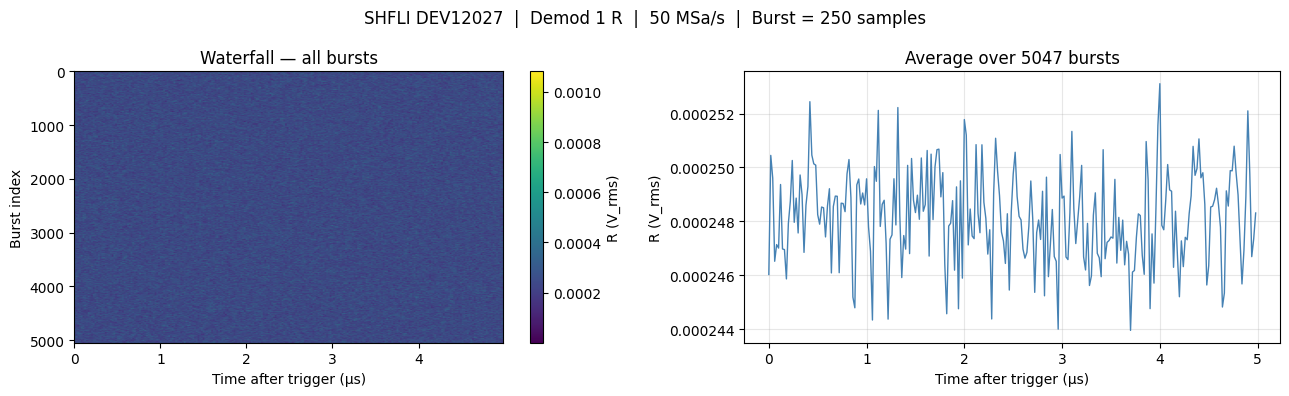

In [62]:
if all_bursts:
    bursts_arr = np.array(all_bursts)   # shape (N_bursts, BURST_LEN)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Waterfall image
    im = axes[0].imshow(
        bursts_arr,
        aspect='auto',
        extent=[t_axis[0], t_axis[-1], len(all_bursts), 0],
        origin='upper'
    )
    plt.colorbar(im, ax=axes[0], label='R (V_rms)')
    axes[0].set_xlabel('Time after trigger (µs)')
    axes[0].set_ylabel('Burst index')
    axes[0].set_title('Waterfall — all bursts')

    # Average
    r_mean = bursts_arr.mean(axis=0)
    axes[1].plot(t_axis, r_mean, lw=1.0, color='steelblue')
    axes[1].set_xlabel('Time after trigger (µs)')
    axes[1].set_ylabel('R (V_rms)')
    axes[1].set_title(f'Average over {len(all_bursts)} bursts')
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f'SHFLI {DEVICE_ID.upper()}  |  Demod {DEMOD_INDEX+1} R  |  {DEMOD_RATE/1e6:.0f} MSa/s  |  Burst = {BURST_LEN} samples')
    plt.tight_layout()
    plt.show()
else:
    print("No bursts collected.")

## Data Loss Analysis

Three independent checks:

1. **`dataloss` flag** — set by the firmware when the internal FIFO overflowed between two bursts
2. **NaN samples** — the DAQ fills missing samples with NaN when it cannot reconstruct them
3. **Trigger-number gaps** — consecutive trigger numbers should increment by 1; any jump means entire bursts were dropped and never returned by `read()`

  Total bursts collected   : 5047
  Total samples            : 1261750
----------------------------------------------------
  Dataloss flag set        : 0  (0.0 %)
  Bursts with NaN          : 0  (0.0 %)
  Total NaN samples        : 0  (0.000 %)
  Trigger-number gaps      : 0  (≈ 0 bursts dropped)
  ✓ No data loss detected.


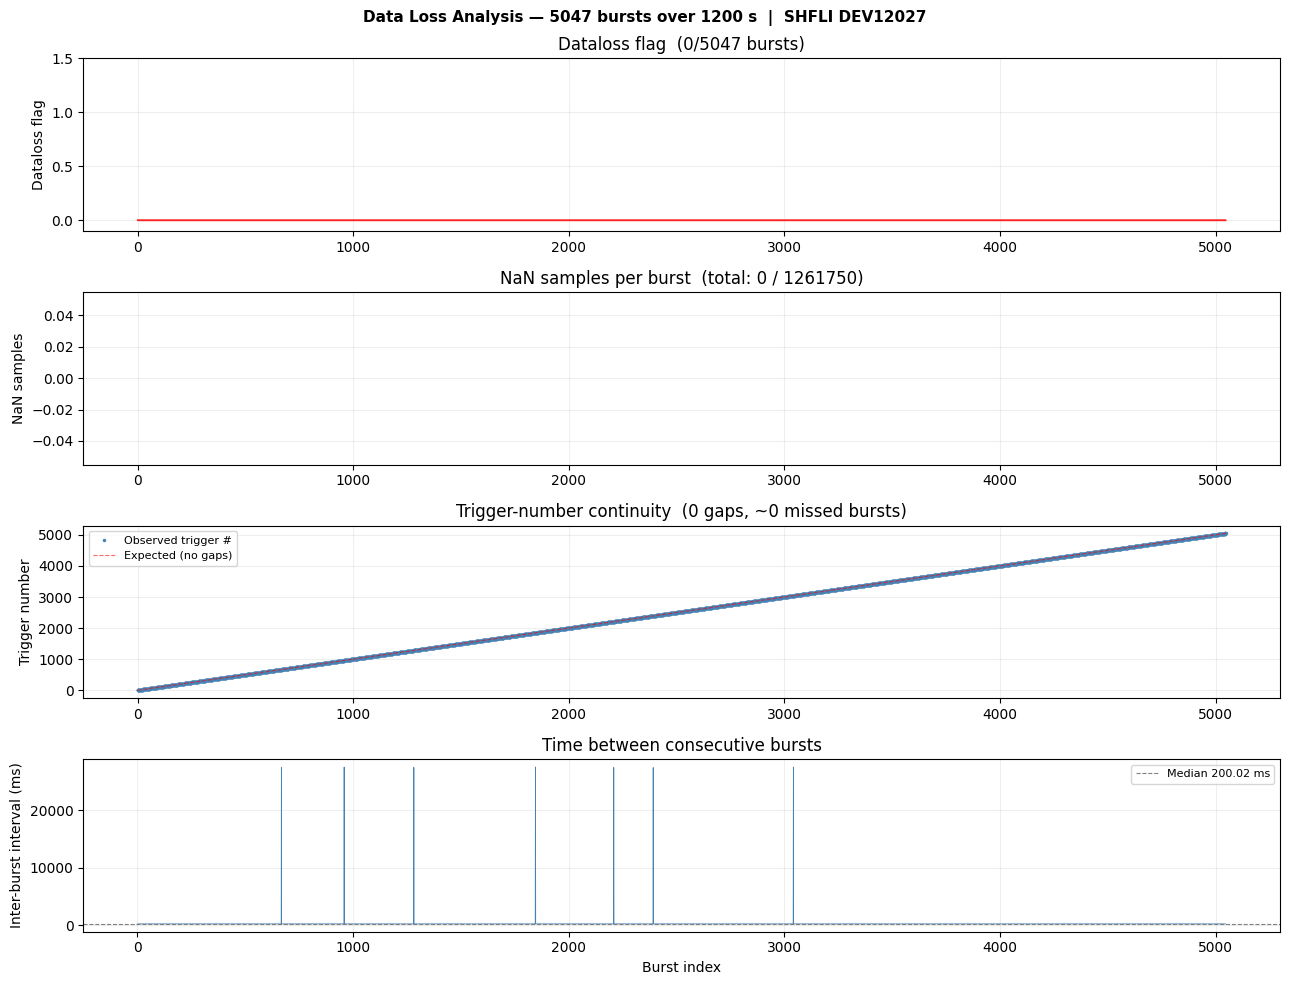

In [63]:
if not burst_meta:
    print("No burst metadata — run the acquisition cell first.")
else:
    n_total = len(burst_meta)

    # ── Unpack metadata arrays ────────────────────────────────────────────────
    dataloss_arr  = np.array([m['dataloss']    for m in burst_meta], dtype=bool)
    flags_arr     = np.array([m['flags']       for m in burst_meta], dtype=int)
    trig_arr      = np.array([m['trigger_num'] for m in burst_meta], dtype=float)
    ts_arr        = np.array([m['timestamp']   for m in burst_meta], dtype=float)
    has_nan_arr   = np.array([m['has_nan']     for m in burst_meta], dtype=bool)
    n_nan_arr     = np.array([m['n_nan']       for m in burst_meta], dtype=int)
    burst_idx     = np.arange(n_total)

    # ── Check 1: dataloss flag ────────────────────────────────────────────────
    n_dataloss = dataloss_arr.sum()

    # ── Check 2: NaN samples ─────────────────────────────────────────────────
    n_nan_bursts      = has_nan_arr.sum()
    total_nan_samples = n_nan_arr.sum()
    total_samples     = n_total * BURST_LEN

    # ── Check 3: trigger-number gaps ─────────────────────────────────────────
    trig_diffs   = np.diff(trig_arr)
    gap_mask     = trig_diffs > 1                      # expected step = 1
    n_gaps       = gap_mask.sum()
    missed_total = int((trig_diffs[gap_mask] - 1).sum()) if n_gaps else 0

    # ── Timestamps between bursts ─────────────────────────────────────────────
    dt_bursts = np.diff(ts_arr)                        # inter-burst interval (s)

    # ── Summary print ─────────────────────────────────────────────────────────
    print("=" * 52)
    print(f"  Total bursts collected   : {n_total}")
    print(f"  Total samples            : {total_samples}")
    print("-" * 52)
    print(f"  Dataloss flag set        : {n_dataloss}  ({100*n_dataloss/n_total:.1f} %)")
    print(f"  Bursts with NaN          : {n_nan_bursts}  ({100*n_nan_bursts/n_total:.1f} %)")
    print(f"  Total NaN samples        : {total_nan_samples}  ({100*total_nan_samples/total_samples:.3f} %)")
    print(f"  Trigger-number gaps      : {n_gaps}  (≈ {missed_total} bursts dropped)")
    print("=" * 52)
    if n_dataloss == 0 and n_nan_bursts == 0 and n_gaps == 0:
        print("  ✓ No data loss detected.")
    else:
        print("  ✗ Data loss detected — see plots below.")

    # ── Plots ─────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=False)

    # 1. Dataloss flag per burst
    ax = axes[0]
    ax.step(burst_idx, dataloss_arr.astype(int), where='mid', color='red', lw=1)
    ax.fill_between(burst_idx, dataloss_arr.astype(int), step='mid', color='red', alpha=0.3)
    ax.set_ylabel('Dataloss flag')
    ax.set_ylim(-0.1, 1.5)
    ax.set_title(f'Dataloss flag  ({n_dataloss}/{n_total} bursts)')
    ax.grid(True, alpha=0.2)

    # 2. NaN samples per burst
    ax = axes[1]
    ax.bar(burst_idx, n_nan_arr, color='orange', width=1)
    ax.set_ylabel('NaN samples')
    ax.set_title(f'NaN samples per burst  (total: {total_nan_samples} / {total_samples})')
    ax.grid(True, alpha=0.2)

    # 3. Trigger number vs burst index (gaps show as jumps above the diagonal)
    ax = axes[2]
    ax.plot(burst_idx, trig_arr, '.', ms=3, color='steelblue', label='Observed trigger #')
    ideal = trig_arr[0] + burst_idx
    ax.plot(burst_idx, ideal, 'r--', lw=0.8, alpha=0.6, label='Expected (no gaps)')
    if n_gaps:
        gap_positions = burst_idx[1:][gap_mask]
        ax.vlines(gap_positions, trig_arr.min(), trig_arr.max(),
                  color='red', lw=0.8, alpha=0.5, label=f'Gaps ({n_gaps})')
    ax.set_ylabel('Trigger number')
    ax.set_title(f'Trigger-number continuity  ({n_gaps} gaps, ~{missed_total} missed bursts)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

    # 4. Inter-burst interval
    ax = axes[3]
    ax.plot(burst_idx[1:], dt_bursts * 1e3, lw=0.6, color='steelblue')
    median_dt = np.median(dt_bursts) * 1e3
    ax.axhline(median_dt, color='gray', ls='--', lw=0.8, label=f'Median {median_dt:.2f} ms')
    ax.set_ylabel('Inter-burst interval (ms)')
    ax.set_xlabel('Burst index')
    ax.set_title('Time between consecutive bursts')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

    plt.suptitle(f'Data Loss Analysis — {n_total} bursts over {TIME_WINDOW:.0f} s  |  SHFLI {DEVICE_ID.upper()}',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [5]:
640/1.17

547.008547008547